In [35]:
import json
from datetime import timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from bisect import bisect_right  # <-- te faltaba
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize

import importlib
import obspy
from obspy import read, UTCDateTime, Stream
from obspy.core.util import AttribDict
from obspy.geodetics.base import gps2dist_azimuth
from obspy.imaging.cm import obspy_sequential
from obspy.signal.array_analysis import array_processing
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

In [36]:
from pathlib import Path
import sys, importlib

import pandas as pd
from obspy import UTCDateTime

# 👇 apunta al folder donde vive qq_helpers.py
HELPERS_DIR = "/home/elizabeth/soft/src/QuickQuake/quickquake"
if HELPERS_DIR not in sys.path:
    sys.path.insert(0, HELPERS_DIR)

import qq_helpers as h
importlib.reload(h)   # solo si acabas de editar qq_helpers.py
print("helpers:", h.__file__)


helpers: /home/elizabeth/soft/src/QuickQuake/quickquake/qq_helpers.py


In [37]:
# Paths
DATA_ROOT = Path("/home/elizabeth/soft/src/QuickQuake/data")
CATALOG_CSV   = DATA_ROOT / "merged/output/GAMMA_hypodd_catalog.csv"
PICKS_CSV     = DATA_ROOT / "merged/input/GAMMA_picks_cleaned.csv"
STATIONS_JSON = DATA_ROOT / "merged/input/GAMMA_station_list.json"

catalog, picks, stations = h.load_inputs(CATALOG_CSV, PICKS_CSV, STATIONS_JSON)
print("Loaded:", catalog.shape, picks.shape, stations.shape)


Loaded: (24, 6) (1161, 9) (11, 4)


In [38]:
# Waveform index + cache
INDEX_PATH = Path("/home/elizabeth/soft/src/QuickQuake/waveform_index.pkl")

if INDEX_PATH.exists():
    wf_index = h.WaveformIndex.load(INDEX_PATH)
else:
    wf_index = h.WaveformIndex.build([DATA_ROOT], glob_pattern="**/waveforms/*.mseed")
    wf_index.save(INDEX_PATH)

cache = h.StreamCache()
print("Indexed mseed files:", len(wf_index.df))


Indexed mseed files: 2


In [39]:
# (Opcional) sanity check rápido (solo una vez)
print("Catalog time min/max:", catalog["datetime"].min(), catalog["datetime"].max())
print("Waveforms time min/max:",
      pd.to_datetime(wf_index.df["t0"], unit="s", utc=True).min(),
      pd.to_datetime(wf_index.df["t1"], unit="s", utc=True).max())


Catalog time min/max: 2021-07-29 08:16:19.590000+00:00 2021-07-29 20:34:07.480000+00:00
Waveforms time min/max: 2021-07-29 08:00:00+00:00 2021-07-30 00:00:00+00:00


MOVEOUT PLOT

21 files: ['2021-07-29T08-00-00.mseed', '2021-07-29T16-00-00.mseed'] stations: 11


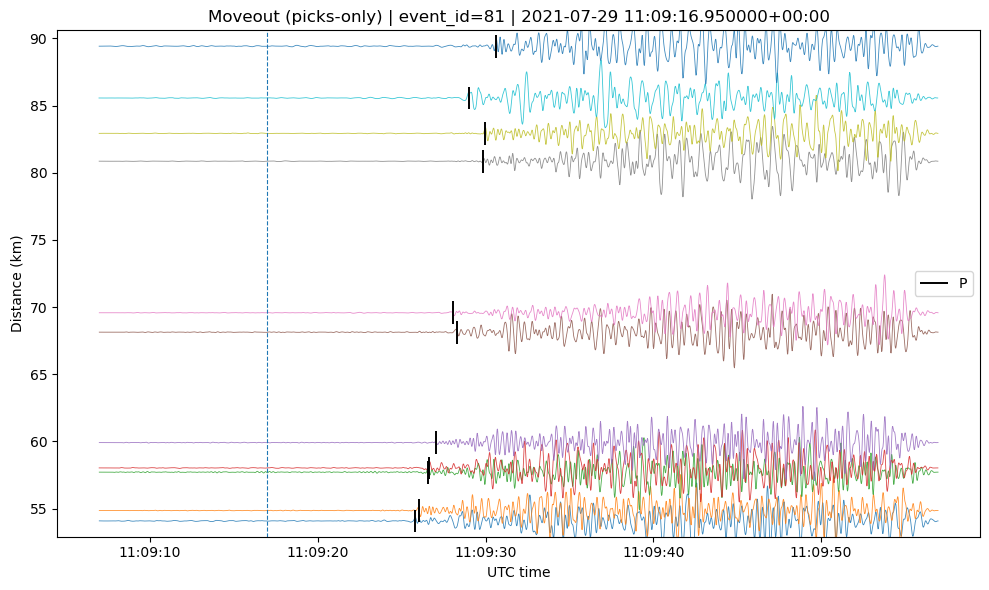

In [24]:
# Plot de varios eventos
for i, row in catalog.iloc[21:22].iterrows():
    fig, ax, meta = h.plot_event_moveout_picks_only(
        row_event=row,
        picks=picks,
        stations=stations,
        cache=cache,
        wf_index=wf_index,
        pre_s=10,
        post_s=40,
        freqmin=1.0,
        freqmax=5.0,
        p_color="black",
        s_color="red",
        line_height_km=1.7,
        line_width=1.4,
        wiggle_frac_of_spacing=1.2,
    )

    print(i, "files:", [Path(f).name for f in meta["files"]], "stations:", len(meta["stations_used"]))


SPECTROGRAM

/home/elizabeth/soft/src/QuickQuake/quickquake/qq_helpers.py:993: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  cbar = fig.colorbar(last_im, ax=axes[:, 1], shrink=0.85, pad=0.01)


files: ['2021-07-29T08-00-00.mseed', '2021-07-29T16-00-00.mseed']
stations used: 11


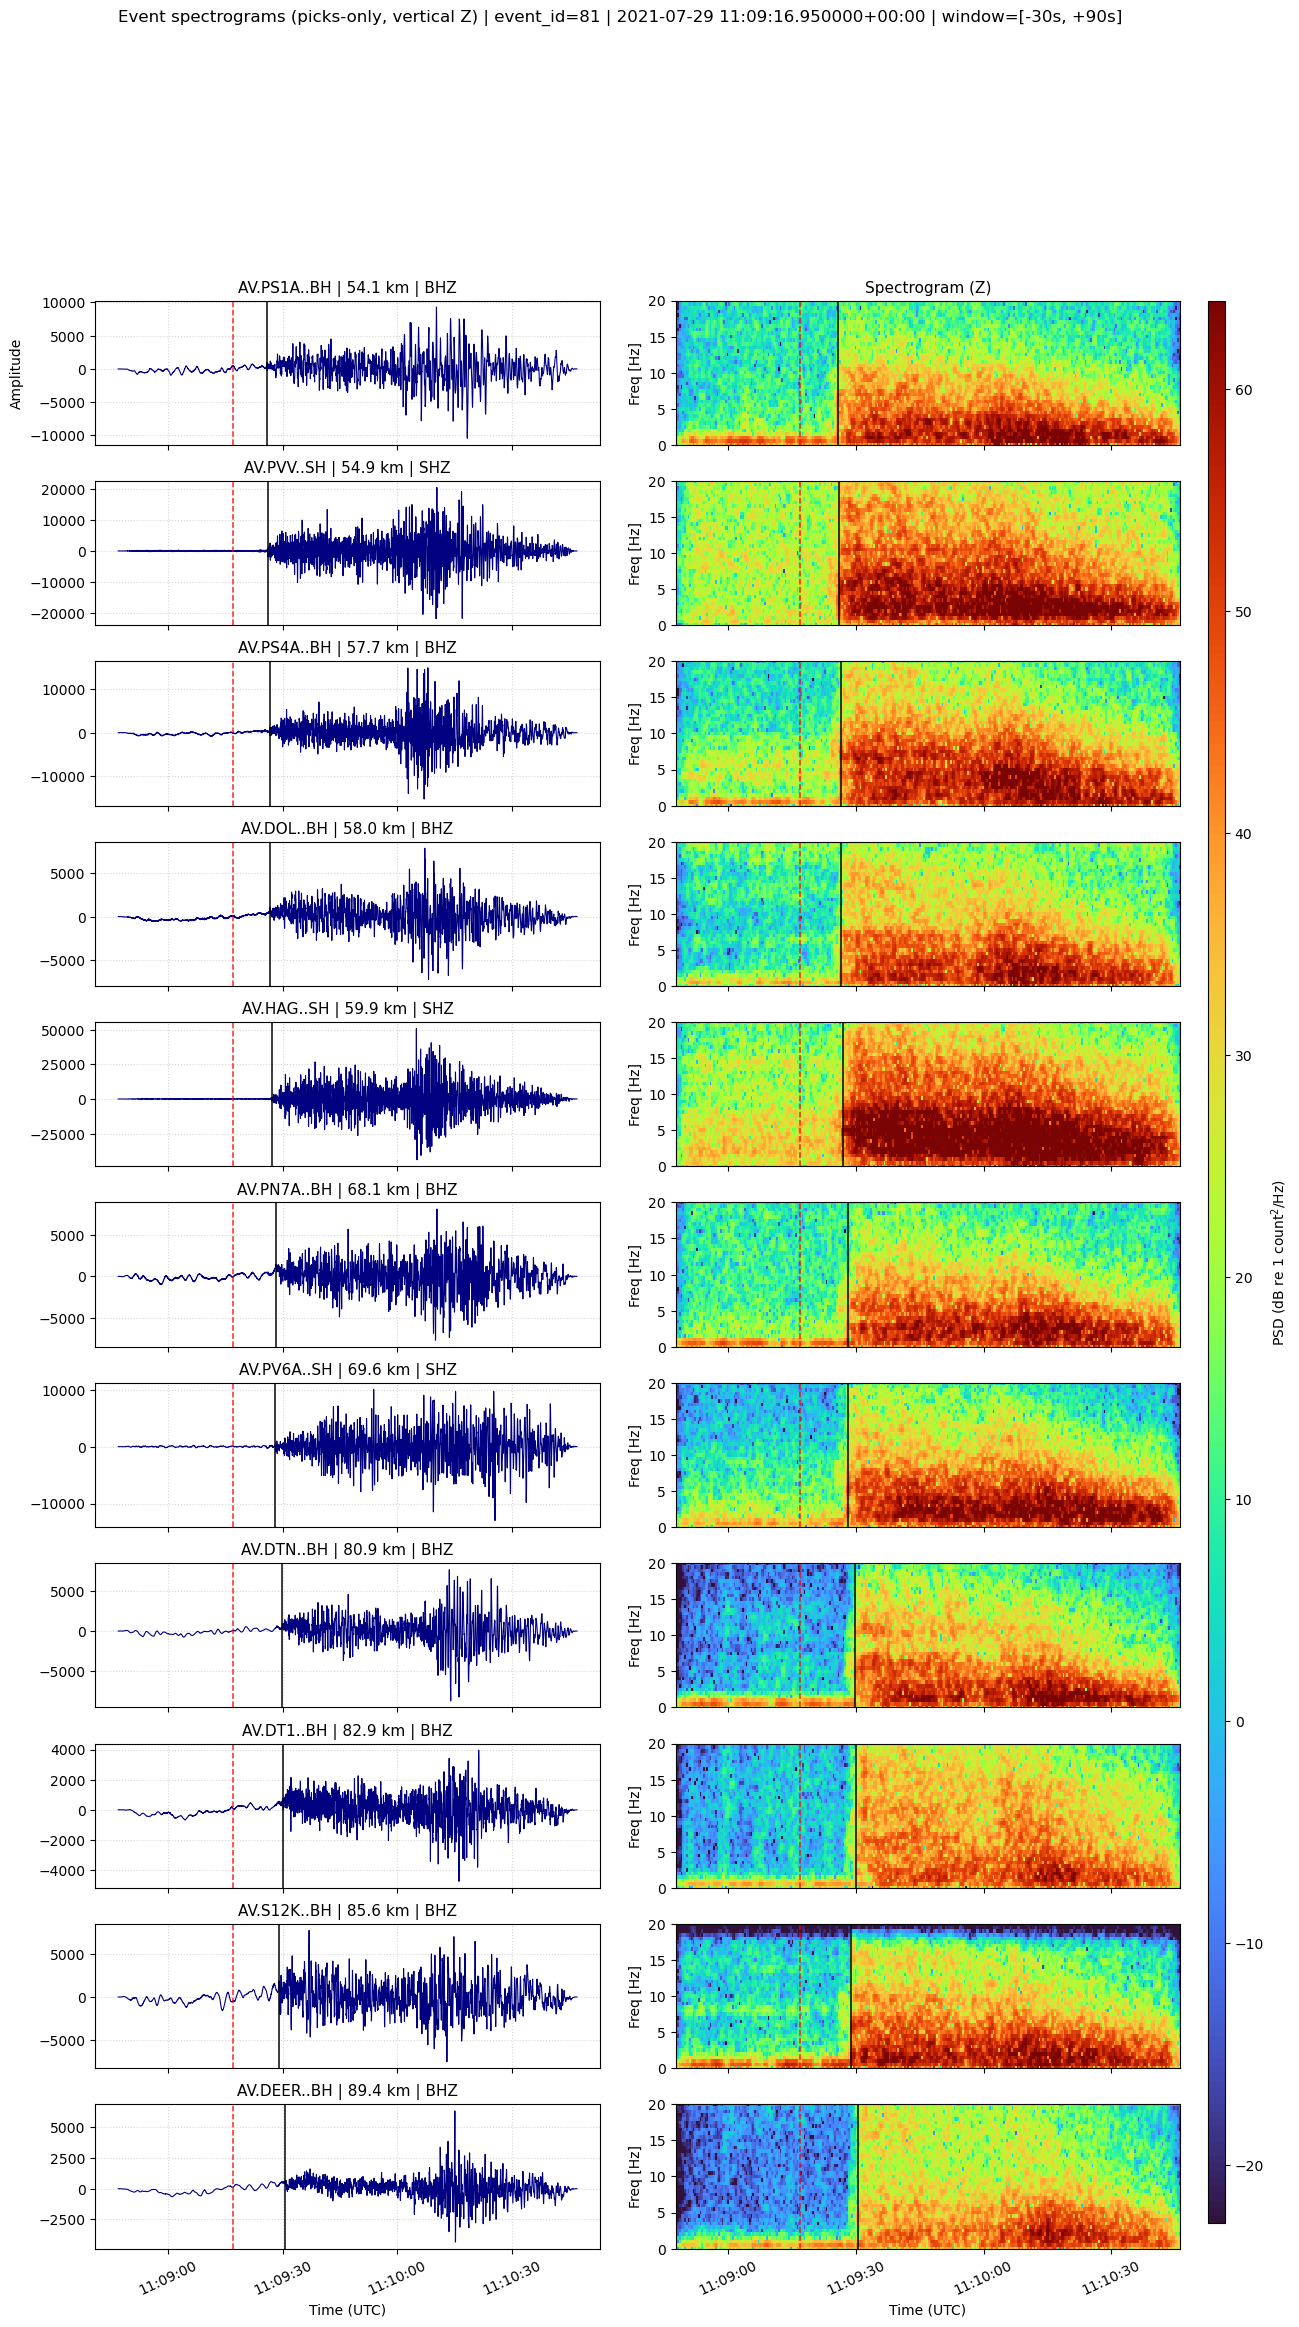

In [32]:
for i, row in catalog.iloc[21:22].iterrows():

    fig, axes, meta = h.plot_event_spectrograms_vertical_picks_only(
        row_event=row,
        picks=picks,
        stations=stations,
        cache=cache,
        wf_index=wf_index,
        pre_s=30,
        post_s=90,
        window_s=2,
        overlap_frac=0.8,
        freq_min=0,
        freq_max=20,
        # opcional: filtro para limpiar la traza antes del spectrogram
        # bp_freqmin=1.0,
        # bp_freqmax=10.0,
    )

    print("files:", [Path(f).name for f in meta["files"]])
    print("stations used:", len(meta["stations_used"]))


In [40]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"   # o "vscode" si estás en VSCode

fig = h.plot_catalog_3d_topo_seismicity(
    catalog=catalog,
    mode="time",
    show=True,   # 👈 para que haga fig.show() como tu notebook
)



grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -161.800065 to -161.804166667
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -160.670524 to -160.666666667
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 55.124044 to 55.1208333333
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.323458 to 55.325


In [41]:
fig = h.plot_catalog_3d_topo_seismicity(
    catalog=catalog,
    mode="year_month",
    year=2021,
    show=True,
)


grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -161.800065 to -161.804166667
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -160.670524 to -160.666666667
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 55.124044 to 55.1208333333
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.323458 to 55.325
